# Feedback Alignment in Convolutional Neural Network for Medical AI

In [1]:
import time
import os
import h5py
import numpy as np
import pandas as pd
import gc

import matplotlib.pyplot as plt
import seaborn as sns

from tqdm import tqdm

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, classification_report, roc_auc_score

import torch
from torch import nn
from torch.nn import functional as F
from torch.utils.data import Dataset, DataLoader, random_split
import torch.optim as optim
from torch.optim.lr_scheduler import CosineAnnealingWarmRestarts
from torchvision import transforms
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Seed
seed = 42
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)

os.makedirs("cnn_learning_results/models", exist_ok=True)
os.makedirs("cnn_learning_results/plots", exist_ok=True)

DATA_PATH = "pcam_data"

import warnings
warnings.filterwarnings("ignore")

Using device: cuda


Dataset


PatchCamelyon (PCam) Histopathology Images, h5. 96x96, RBG --> [N, 96, 96, 3]

Training Images shape: (262144, 96, 96, 3)
Labels shape: (262144,)


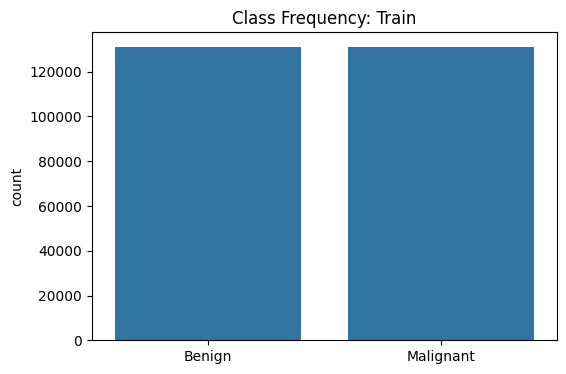

In [2]:
# Training Data
xtr_path = fr"{DATA_PATH}/train/train_img.h5"
ytr_path = fr"{DATA_PATH}/train/train_label.h5"
with h5py.File(xtr_path, 'r') as f:
    X_train = np.array(f['x'][:262144])  # [N, 96, 96, 3]
with h5py.File(ytr_path, 'r') as f:
    y_train = np.array(f['y'][:262144]).squeeze()  # [N, 1, 1, 1] squeezed to [N, ]
print(f"Training Images shape: {X_train.shape}\nLabels shape: {y_train.shape}")

plt.figure(figsize=(6, 4))
sns.countplot(x=y_train)
plt.title("Class Frequency: Train")
plt.xticks([0, 1], ["Benign", "Malignant"])
plt.show()

Val Images shape: (32768, 96, 96, 3)
Labels shape: (32768,)


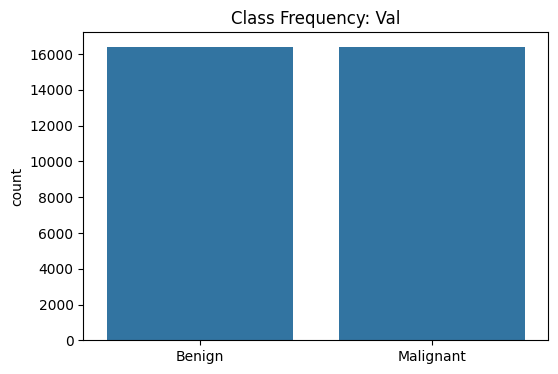

In [3]:
# Val Data
xv_path = fr"{DATA_PATH}/val/val_img.h5"
yv_path = fr"{DATA_PATH}/val/val_label.h5"
with h5py.File(xv_path, 'r') as f:
    X_val = np.array(f['x'])
with h5py.File(yv_path, 'r') as f:
    y_val = np.array(f['y']).squeeze()
print(f"Val Images shape: {X_val.shape}\nLabels shape: {y_val.shape}")

plt.figure(figsize=(6, 4))
sns.countplot(x=y_val)
plt.title("Class Frequency: Val")
plt.xticks([0, 1], ["Benign", "Malignant"])
plt.show()

Test Images shape: (32768, 96, 96, 3)
Labels shape: (32768,)


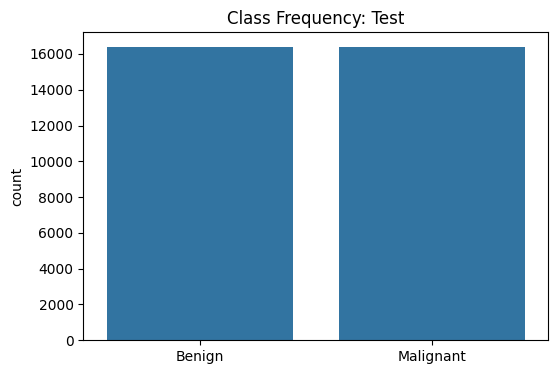

In [4]:
# Test Data
xte_path = fr"{DATA_PATH}/test/test_img.h5"
yte_path = fr"{DATA_PATH}/test/test_label.h5"
with h5py.File(xte_path, 'r') as f:
    X_test = np.array(f['x'])
with h5py.File(yte_path, 'r') as f:
    y_test = np.array(f['y']).squeeze()
print(f"Test Images shape: {X_test.shape}\nLabels shape: {y_test.shape}")

plt.figure(figsize=(6, 4))
sns.countplot(x=y_test)
plt.title("Class Frequency: Test")
plt.xticks([0, 1], ["Benign", "Malignant"])
plt.show()

^ Ensure balanced for accurate metrics

Dataset object & Loader

In [5]:
# Image trasnformations
def get_transform(split, mean, std):
    # robustness, overfitting prevention
    if split.lower() == 'train':
        return transforms.Compose([
            transforms.ToPILImage(),

            transforms.RandomRotation(20), # +- 20 degrees

            # transforms.RandomResizedCrop(
            #     size=96,            # output size is 96x96
            #     scale=(0.8, 1.0),   # crop 80-100% of area
            #     ratio=(0.9, 1.1)    # keep aspect ratio roughly square
            # ),

            transforms.RandomAffine(
                degrees=0,                 # rotation already applied
                translate=(0.1, 0.1),      # shift up to +-10% of image
                scale=(0.9, 1.1),          # zoom in/out
                shear=10                   # slant up to 10 degrees
            ),

            transforms.ColorJitter(
                brightness=0.2,
                contrast=0.2,
                saturation=0.2,
                hue=0.1
            ),

            # transforms.GaussianBlur(
            #     kernel_size=(3, 7), 
            #     sigma=(0.1, 2.0)
            # ),


            transforms.ToTensor(),
            transforms.Normalize(mean=mean, std=std)
        ])
    
    else:  # 'val', 'test' --> no transforms
        return transforms.Compose([
            transforms.ToPILImage(),
            transforms.ToTensor(),
            transforms.Normalize(mean=mean, std=std)
        ])

# Dataset class
class PCamDataset(Dataset):
    def __init__(self, images, labels, transform=None):
        self.images = images
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        image = self.images[idx].astype(np.uint8)
        label = int(self.labels[idx])
        if self.transform:
            image = self.transform(image)
        return image, label

In [6]:
# data = X_train
# N = data.shape[0]
# mean = np.zeros(3)
# std = np.zeros(3)
# total = 0
# for i in range(0, N, 2**13):
#     batch = data[i: i+2**13].astype(np.float32) / 255.0
#     batch = batch.reshape(-1, 3)
#     mean += batch.sum(axis=0)
#     std += (batch**2).sum(axis=0)
#     total += batch.shape[0]
# mean /= total
# std = np.sqrt(std/total - mean**2)
# mean = mean.tolist()
# std = std.tolist()
mean  = [0.2222222222222222, 0.2222222222222222, 0.2222222222222222]  # PCam calculated mean
std   = [0.41573970964154905, 0.41573970964154905, 0.41573970964154905] # PCam calculated std
print(f"Mean: {mean}, Std: {std}")

train_loader = DataLoader(PCamDataset(X_train, y_train, transform=get_transform('train', mean, std)), 
                          batch_size=256, shuffle=True, 
                          num_workers=0, 
                          pin_memory=True)
val_loader   = DataLoader(PCamDataset(X_val, y_val, get_transform('val', mean, std)), batch_size=256, shuffle=False, num_workers=0, pin_memory=True)
test_loader  = DataLoader(PCamDataset(X_test, y_test, transform=get_transform('test', mean, std)), batch_size=256, shuffle=False, num_workers=0, pin_memory=True)

Mean: [0.2222222222222222, 0.2222222222222222, 0.2222222222222222], Std: [0.41573970964154905, 0.41573970964154905, 0.41573970964154905]


CNN Architecture

Res-Net Style

In [7]:
class BasicBlock(nn.Module):
    def __init__(self, in_ch, out_ch, use_bn=True, use_dropout=False):
        super().__init__()
        self.use_bn = use_bn
        self.use_dropout = use_dropout

        self.conv1 = nn.Conv2d(in_ch, out_ch, kernel_size=3, padding="same", bias=False)
        self.bn1 = nn.BatchNorm2d(out_ch) if use_bn else nn.Identity()

        self.conv2 = nn.Conv2d(out_ch, out_ch, kernel_size=3, padding="same", bias=False)
        self.bn2 = nn.BatchNorm2d(out_ch) if use_bn else nn.Identity()

        self.drop = nn.Dropout2d(p=0.2) if use_dropout else nn.Identity()

        self.shortcut = (
            nn.Sequential(
                nn.Conv2d(in_ch, out_ch, kernel_size=1, bias=False),
                nn.BatchNorm2d(out_ch)
            ) if in_ch != out_ch else nn.Identity()
        )

    def forward(self, x):
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out += self.shortcut(x)
        out = F.relu(out)
        out = self.drop(out)
        return out


class PCamCNN(nn.Module):
    def __init__(self, num_classes=2, blocks=3, bn_last=True, dropout_last=True):
        super().__init__()
        self.stem = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding="same", bias=False),
            nn.BatchNorm2d(32),
            nn.ReLU()
        )

        self.pool1 = nn.MaxPool2d(2)

        # Stage 1
        self.stage1 = nn.Sequential(
            BasicBlock(32, 32),
            BasicBlock(32, 32)
        )

        # Stage 2
        self.stage2 = nn.Sequential(
            BasicBlock(32, 64),
            BasicBlock(64, 64, use_bn=True, use_dropout=(blocks==2 and dropout_last))
        )

        # Stage 3
        if blocks == 3:
            self.stage3 = nn.Sequential(
                nn.MaxPool2d(2),
                BasicBlock(64, 128),
                BasicBlock(128, 128, use_bn=bn_last, use_dropout=dropout_last)
            ); in_features = 128
        else:
            self.stage3 = nn.Identity()
            in_features = 64

        self.pool = nn.AdaptiveAvgPool2d((1, 1))

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(in_features, 128),
            nn.ReLU(),
            nn.Dropout(p=0.5),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(p=0.3),
            nn.Linear(64, num_classes)
        )

    def forward(self, x):
        x = self.stem(x)
        x = self.stage1(x)
        x = self.pool1(x)
        x = self.stage2(x)
        x = self.stage3(x)
        x = self.pool(x)
        return self.classifier(x)

### Backpropagation Experiments


=== Running Config 1: {'blocks': 2, 'bn_last': True, 'dropout_last': True} ===



Config 1: 100%|██████████| 32/32 [6:25:20<00:00, 722.51s/it, Epoch=32/32, Train Acc=0.9347, Val Acc=0.8905, Train Loss=0.1737, Val Loss=0.3270]  



Classification Report{'blocks': 2, 'bn_last': True, 'dropout_last': True}:
               precision    recall  f1-score   support

           0       0.84      0.93      0.88     16391
           1       0.92      0.83      0.87     16377

    accuracy                           0.88     32768
   macro avg       0.88      0.88      0.88     32768
weighted avg       0.88      0.88      0.88     32768

Final Accuracy {'blocks': 2, 'bn_last': True, 'dropout_last': True}: 0.8790, F1: 0.8786, ROC-AUC: 0.9535



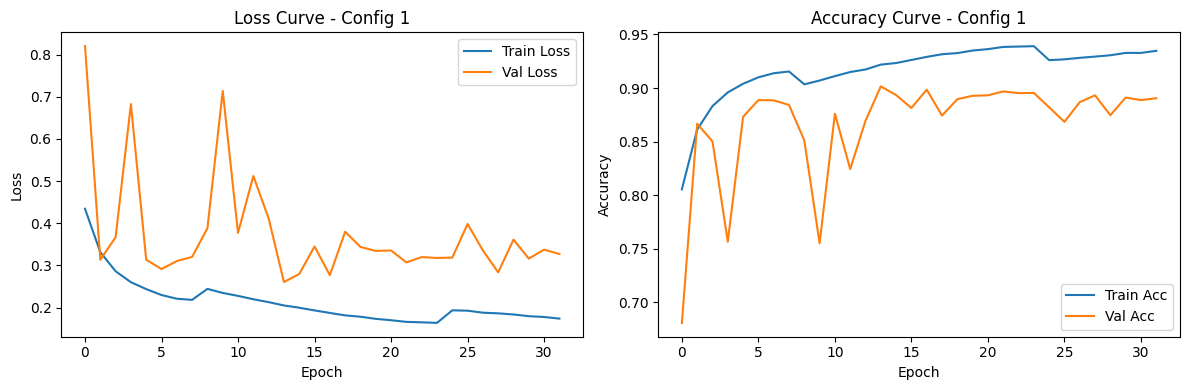


=== Running Config 2: {'blocks': 3, 'bn_last': False, 'dropout_last': False} ===



Config 2: 100%|██████████| 32/32 [6:50:17<00:00, 769.31s/it, Epoch=32/32, Train Acc=0.9563, Val Acc=0.8713, Train Loss=0.1215, Val Loss=0.3650]  



Classification Report{'blocks': 3, 'bn_last': False, 'dropout_last': False}:
               precision    recall  f1-score   support

           0       0.77      0.98      0.86     16391
           1       0.98      0.71      0.82     16377

    accuracy                           0.85     32768
   macro avg       0.87      0.85      0.84     32768
weighted avg       0.87      0.85      0.84     32768

Final Accuracy {'blocks': 3, 'bn_last': False, 'dropout_last': False}: 0.8466, F1: 0.8437, ROC-AUC: 0.9536



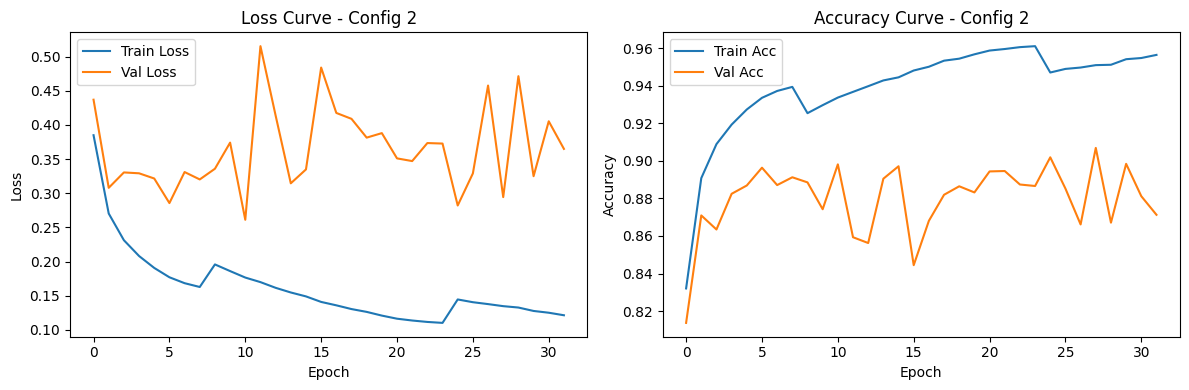


=== Final Summary Across All Configs ===

 Config #  blocks  bn_last  dropout_last  Test Accuracy  F1 Score  ROC-AUC
        1       2     True          True       0.878967  0.878641 0.953503
        2       3    False         False       0.846558  0.843659 0.953608


In [ ]:
EPOCHS = 32

configs = [
    {"blocks": 2, "bn_last": True,  "dropout_last": True},      
    {"blocks": 3, "bn_last": False, "dropout_last": False}, 
]

torch.backends.cudnn.benchmark = True
torch.backends.cudnn.deterministic = False

scaler = torch.amp.GradScaler()

# Run experiments
final_results = []
for i, cfg in enumerate(configs):
    print(f"\n=== Running Config {i+1}: {cfg} ===\n")

    model = PCamCNN(**cfg).to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.AdamW(model.parameters(), lr=3e-4, weight_decay=1e-4)
    scheduler = CosineAnnealingWarmRestarts(optimizer, T_0=8, T_mult=2, eta_min=1e-6)

    train_losses, val_losses = [], []
    train_accs, val_accs = [], []

    pbar = tqdm(range(EPOCHS), desc=f"Config {i+1}", leave=True)
    for epoch in pbar:
        model.train()
        correct_train, total_train, train_loss = 0, 0, 0.0

        for batch_idx, (images, labels) in enumerate(train_loader):
            images, labels = images.to(device, non_blocking=True), labels.to(device, non_blocking=True)

            optimizer.zero_grad()
            with torch.amp.autocast(device_type='cuda'):  
                outputs = model(images)
                loss = criterion(outputs, labels)
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()

            train_loss += loss.item()*images.size(0)
            preds = outputs.argmax(dim=1)
            correct_train += (preds==labels).sum().item()
            total_train += labels.size(0)

            scheduler.step(epoch + batch_idx / len(train_loader))

        train_loss /= total_train ; train_losses.append(train_loss)
        train_acc = correct_train / total_train ; train_accs.append(train_acc)
        
        # Eval
        model.eval()
        val_correct, val_total, val_loss = 0, 0, 0.0
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device, non_blocking=True), labels.to(device, non_blocking=True)
                with torch.amp.autocast(device_type='cuda'):
                    outputs = model(images)
                    loss = criterion(outputs, labels)
                val_loss += loss.item()*images.size(0)
                preds = outputs.argmax(dim=1)
                val_correct += (preds==labels).sum().item()
                val_total += labels.size(0)
        val_loss /= val_total ; val_losses.append(val_loss)
        val_acc = val_correct / val_total ; val_accs.append(val_acc)
        
    
        pbar.set_postfix({
            'Epoch': f"{epoch+1}/{EPOCHS}",
            'Train Acc': f"{train_acc:.4f}",
            'Val Acc': f"{val_acc:.4f}",
            'Train Loss': f"{train_loss:.4f}",
            'Val Loss': f"{val_loss:.4f}"
        })

    # Final Test Performance
    model.eval()
    all_preds = []
    all_labels = []
    all_probs = []
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device, non_blocking=True), labels.to(device, non_blocking=True)
            with torch.amp.autocast(device_type='cuda'):
                outputs = model(images)
            preds = outputs.argmax(dim=1)
            all_probs.extend(outputs.softmax(dim=1).cpu().numpy())
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    acc = accuracy_score(all_labels, all_preds)
    f1 = f1_score(all_labels, all_preds, average="macro")
    roc = roc_auc_score(all_labels, np.array(all_probs)[:, 1])

    print(f"\nClassification Report{cfg}:\n", classification_report(all_labels, all_preds))
    print(f"Final Accuracy {cfg}: {acc:.4f}, F1: {f1:.4f}, ROC-AUC: {roc:.4f}\n")

    final_results.append((cfg, acc, f1, roc))

    # Plot losses and accuracies
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.plot(train_losses, label='Train Loss')
    plt.plot(val_losses, label='Val Loss')
    plt.title(f"Loss Curve - Config {i+1}")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(train_accs, label='Train Acc')
    plt.plot(val_accs, label='Val Acc')
    plt.title(f"Accuracy Curve - Config {i+1}")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()

    plt.tight_layout()
    plt.show()

    del model, optimizer, scheduler
    model = optimizer = scheduler = None
    torch.cuda.empty_cache()
    gc.collect()

# Summary table
summary_df = pd.DataFrame([
    {
        'Config #': i+1,
        'blocks': cfg['blocks'],
        'bn_last': cfg['bn_last'],
        'dropout_last': cfg['dropout_last'],
        'Test Accuracy': acc,
        'F1 Score': f1,
        'ROC-AUC': roc
    }
    for i, (cfg, acc, f1, roc) in enumerate(final_results)
])

print("\n=== Final Summary Across All Configs ===\n")
print(summary_df.to_string(index=False))

### FeedbackAlignment Experiments

Direct Feedback Alignment


=== Config 1: {'blocks': 2, 'bn_last': True, 'dropout_last': True} ===


Config 1: 100%|██████████| 48/48 [8:00:56<00:00, 601.17s/it, TrainAcc=0.7942, Val Acc=0.7531, Train Loss=0.4555, Val Loss=0.5235]  



Classification Report {'blocks': 2, 'bn_last': True, 'dropout_last': True}:
               precision    recall  f1-score   support

           0       0.65      0.90      0.76     16391
           1       0.84      0.52      0.65     16377

    accuracy                           0.71     32768
   macro avg       0.75      0.71      0.70     32768
weighted avg       0.75      0.71      0.70     32768

Final Accuracy {'blocks': 2, 'bn_last': True, 'dropout_last': True}: 0.7131, F1: 0.7025, ROC-AUC: 0.8341



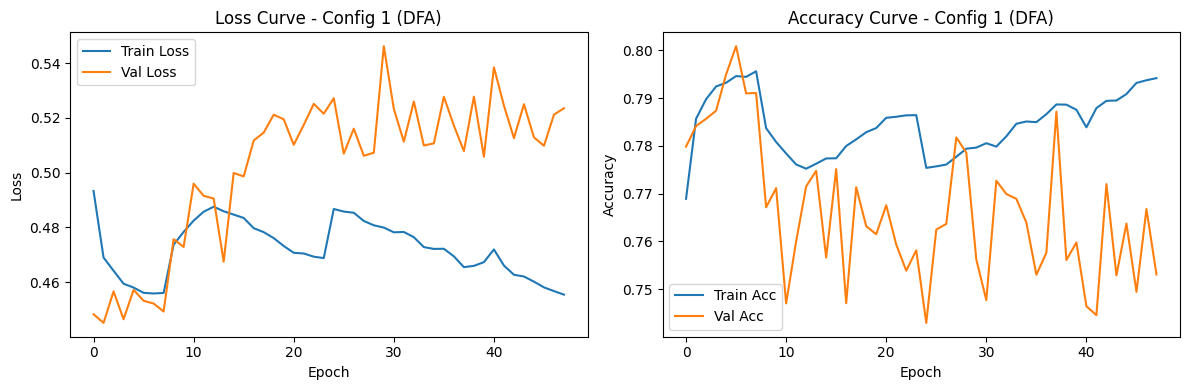


=== Config 2: {'blocks': 3, 'bn_last': False, 'dropout_last': False} ===


Config 2:  81%|████████▏ | 39/48 [7:08:05<1:38:04, 653.86s/it, TrainAcc=0.5000, Val Acc=0.5005, Train Loss=nan, Val Loss=nan]

In [ ]:
HOOK_LAYERS = ['stem', 'stage1', 'stage2', 'stage3']    # DFA Layers
rng = np.random.RandomState(seed)
B, _hooked_tensor_ids = {}, set()
current_dL_dz = None

def init_B(act_shape, num_classes=2, scale=1.0):
    flat = np.prod(act_shape[1:])
    B_np = rng.normal(0, 1/np.sqrt(num_classes), (num_classes, flat)).astype(np.float32)
    Bl = torch.from_numpy(B_np).to(device) * scale
    Bl.requires_grad = False
    return Bl

def make_forward_hook(layer):
    def _forward_hook(_, __, out):
        if not isinstance(out, torch.Tensor): return
        
        if layer not in B:
            B[layer] = init_B(out.shape, num_classes=2)
        
        tid = id(out)
        if tid in _hooked_tensor_ids: return

        def tensor_hook(grad):
            global current_dL_dz
            if current_dL_dz is None:
                print("th.1 autograd")
                return grad
            Bl = B[layer]  # (num_classes, flat)
            dL = current_dL_dz.to(Bl.device, dtype=Bl.dtype)  # (B, num_classes)
            with torch.no_grad():
                grad_flat = torch.matmul(dL, Bl)  # (B, flat) in FP32
            grad_new = grad_flat.view_as(grad).to(grad.dtype)
            return grad_new

        if out.requires_grad:
            out.register_hook(tensor_hook)
            _hooked_tensor_ids.add(tid)
    return _forward_hook

# DFA training (SIMILAR)
configs = [
    {"blocks": 2, "bn_last": True,  "dropout_last": True},      
    {"blocks": 3, "bn_last": False, "dropout_last": False}, 
]

torch.backends.cudnn.benchmark = True
torch.backends.cudnn.deterministic = False

EPOCHS = 48

final_results = []
for i, cfg in enumerate(configs):
    print(f"\n=== Config {i+1}: {cfg} ===")

    model = PCamCNN(**cfg).to(device)

    # attach hooks
    B.clear(); _hooked_tensor_ids.clear()
    handles = [getattr(model, l).register_forward_hook(make_forward_hook(l))
               for l in HOOK_LAYERS if hasattr(model, l)]

    optimizer = optim.AdamW(model.parameters(), lr=3e-4, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(optimizer, T_0=8, T_mult=2, eta_min=1e-6)
    criterion = nn.CrossEntropyLoss()

    train_losses, val_losses = [], []
    train_accs, val_accs = [], []

    pbar = tqdm(range(EPOCHS), desc=f"Config {i+1}", leave=True)
    for epoch in pbar:
        model.train()
        correct, total, loss_sum = 0, 0, 0.0

        for batch_idx, (images, labels) in enumerate(train_loader):
            images, labels = images.to(device, non_blocking=True), labels.to(device, non_blocking=True)
            optimizer.zero_grad(set_to_none=True)

            with torch.cuda.amp.autocast():
                out = model(images)                  
                loss = criterion(out, labels)        
                probs = F.softmax(out, dim=1)    

            # compute dL/dz (cross-entropy derivative)
            y_onehot = F.one_hot(labels, num_classes=probs.shape[1]).float()
            dL_dz = (probs.float() - y_onehot) / images.size(0)   # float32
            current_dL_dz = dL_dz.detach() 

            # backward: inject custom grad
            out.backward(gradient=dL_dz.to(out.dtype))

            optimizer.step()
            scheduler.step(epoch + batch_idx/len(train_loader))

            loss_sum += loss.item() * images.size(0)
            preds = out.argmax(1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
            
            _hooked_tensor_ids.clear()
            current_dL_dz = None

        train_losses.append(loss_sum/total)
        train_accs.append(correct/total)

        # Val
        model.eval()
        val_correct, val_total, val_loss = 0, 0, 0.0
        with torch.no_grad(), torch.cuda.amp.autocast():
            for xb, yb in val_loader:
                xb, yb = xb.to(device, non_blocking=True), yb.to(device, non_blocking=True)
                out = model(xb)
                val_loss += criterion(out, yb).item() * xb.size(0)
                val_correct += (out.argmax(1) == yb).sum().item()
                val_total += yb.size(0)
        val_losses.append(val_loss/val_total)
        val_accs.append(val_correct/val_total)

        pbar.set_postfix({
            "TrainAcc": f"{train_accs[-1]:.4f}", 
            "Val Acc": f"{val_accs[-1]:.4f}",
            "Train Loss": f"{train_losses[-1]:.4f}",
            "Val Loss": f"{val_losses[-1]:.4f}"
            })

    # Final Test Performance
    model.eval()
    all_preds = []
    all_labels = []
    all_probs = []
    with torch.no_grad(), torch.cuda.amp.autocast():
        for images, labels in test_loader:
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)
            outputs = model(images)
            preds = outputs.argmax(dim=1)
            all_probs.extend(outputs.softmax(dim=1).cpu().numpy())
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    acc = accuracy_score(all_labels, all_preds)
    f1 = f1_score(all_labels, all_preds, average="macro")
    roc = roc_auc_score(all_labels, np.array(all_probs)[:, 1])

    print(f"\nClassification Report {cfg}:\n", classification_report(all_labels, all_preds))
    print(f"Final Accuracy {cfg}: {acc:.4f}, F1: {f1:.4f}, ROC-AUC: {roc:.4f}\n")

    final_results.append((cfg, acc, f1, roc))

    # Plots
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.plot(train_losses, label='Train Loss')
    plt.plot(val_losses, label='Val Loss')
    plt.title(f"Loss Curve - Config {i+1} (DFA)")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(train_accs, label='Train Acc')
    plt.plot(val_accs, label='Val Acc')
    plt.title(f"Accuracy Curve - Config {i+1} (DFA)")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()

    plt.tight_layout()
    plt.show()

    for h in handles: h.remove()
    del model, optimizer, scheduler
    model = optimizer = scheduler = None
    torch.cuda.empty_cache(); gc.collect()

summary_df = pd.DataFrame([
    {
        'Config #': i+1,
        'blocks': cfg['blocks'],
        'bn_last': cfg['bn_last'],
        'dropout_last': cfg['dropout_last'],
        'Test Accuracy': acc,
        'F1 Score': f1,
        'ROC-AUC': roc
    }
    for i, (cfg, acc, f1, roc) in enumerate(final_results)
])

print("\n=== Final Summary Across All Configs (DFA) ===\n")
print(summary_df.to_string(index=False))

### As evident, DFA has unstable training on deeper and complex models like CNN. 

### ViT results better